In [266]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [267]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, precision_recall_curve

In [269]:
Ldata = pd.read_csv("C:/Users/JANANI V/Desktop/MDP_GUVI/Datas/Indian_Liver_patient.csv")


In [270]:
Ldata.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

In [271]:
Ldata.columns = [ col.lower().replace(" ","_") for col in Ldata.columns]


In [272]:
Ldata.rename(columns={'total_protiens': 'total_proteins'}, inplace=True)

In [273]:
# Drop categorical column 'gender' since it's not crucial for prediction
Ldata = Ldata.drop(columns=['gender'])

In [274]:

# Identify rows where 'Albumin_and_Globulin_Ratio' is missing
missing_indices = Ldata[Ldata["albumin_and_globulin_ratio"].isnull()].index

# Loop through missing indices to calculate the A/G Ratio
for idx in missing_indices:
    total_proteins = Ldata.loc[idx, "total_proteins"]
    albumin = Ldata.loc[idx, "albumin"]
    # Ensure required values are non-null
    if pd.notnull(total_proteins) and pd.notnull(albumin):
        globulin = total_proteins - albumin
        if globulin > 0:  # Avoid division by zero or negative globulin
            Ldata.loc[idx, "albumin_and_globulin_ratio"] = albumin / globulin



In [275]:
print(Ldata.head())  # Check if columns are removed
print(Ldata.info())  # Confirm structure

   age  total_bilirubin  direct_bilirubin  alkaline_phosphotase  \
0   65              0.7               0.1                   187   
1   62             10.9               5.5                   699   
2   62              7.3               4.1                   490   
3   58              1.0               0.4                   182   
4   72              3.9               2.0                   195   

   alamine_aminotransferase  aspartate_aminotransferase  total_proteins  \
0                        16                          18             6.8   
1                        64                         100             7.5   
2                        60                          68             7.0   
3                        14                          20             6.8   
4                        27                          59             7.3   

   albumin  albumin_and_globulin_ratio  dataset  
0      3.3                        0.90        1  
1      3.2                        0.74        

In [276]:
print("Duplicate Entries in Dataset:", Ldata.duplicated().sum())

Duplicate Entries in Dataset: 13


In [277]:
Ldata = Ldata.drop_duplicates()
print("Duplicate Entries in Dataset after removal:", Ldata.duplicated().sum())

Duplicate Entries in Dataset after removal: 0


In [278]:
Ldata = Ldata.drop_duplicates().reset_index(drop=True)
print(Ldata.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         570 non-null    int64  
 1   total_bilirubin             570 non-null    float64
 2   direct_bilirubin            570 non-null    float64
 3   alkaline_phosphotase        570 non-null    int64  
 4   alamine_aminotransferase    570 non-null    int64  
 5   aspartate_aminotransferase  570 non-null    int64  
 6   total_proteins              570 non-null    float64
 7   albumin                     570 non-null    float64
 8   albumin_and_globulin_ratio  570 non-null    float64
 9   dataset                     570 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 44.7 KB
None


In [279]:
print(Ldata['dataset'].value_counts())  # Shows count for each class

dataset
1    406
2    164
Name: count, dtype: int64


In [280]:
# Convert target labels: Change 1 → 0 (No disease) and 2 → 1 (Liver disease)
Ldata["dataset"] = Ldata["dataset"].replace({1: 0, 2: 1})

print(Ldata["dataset"].value_counts())  # Verify label distribution

dataset
0    406
1    164
Name: count, dtype: int64


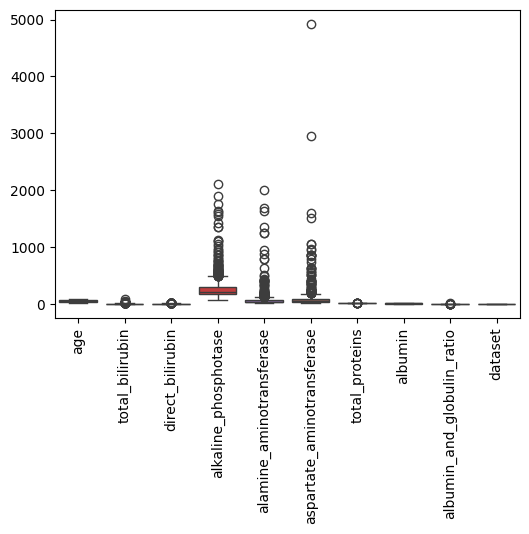

In [281]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(data=Ldata)
plt.xticks(rotation=90)  # Rotate labels for better visibility
plt.show()

In [282]:
from scipy.stats import zscore

z_scores = Ldata.apply(zscore)  # Compute Z-scores for each feature
outliers = (z_scores.abs() > 3).sum()
print(outliers)  # Shows count of potential outliers per column

age                            0
total_bilirubin               17
direct_bilirubin              19
alkaline_phosphotase          14
alamine_aminotransferase      10
aspartate_aminotransferase     6
total_proteins                 3
albumin                        0
albumin_and_globulin_ratio     3
dataset                        0
dtype: int64


In [283]:
import numpy as np

# Apply log transformation iteratively until the values stabilize
for _ in range(15): 
    Ldata[['total_bilirubin', 'direct_bilirubin', 'aspartate_aminotransferase',
           'alamine_aminotransferase', 'alkaline_phosphotase']] = np.log1p(
        Ldata[['total_bilirubin', 'direct_bilirubin', 'aspartate_aminotransferase',
               'alamine_aminotransferase', 'alkaline_phosphotase']]
    )

In [284]:
print(Ldata.shape)  # Compare before & after

(570, 10)


In [285]:
from scipy.stats import zscore

z_scores = Ldata.apply(zscore)  # Compute Z-scores for each feature
outliers = (z_scores.abs() > 3).sum()
print(outliers)  # Shows count of potential outliers per column

age                           0
total_bilirubin               0
direct_bilirubin              0
alkaline_phosphotase          8
alamine_aminotransferase      0
aspartate_aminotransferase    0
total_proteins                3
albumin                       0
albumin_and_globulin_ratio    3
dataset                       0
dtype: int64


In [286]:
print(Ldata.shape)  # Compare before & after

(570, 10)


In [287]:
print(Ldata["dataset"].value_counts())  # Verify label distribution

dataset
0    406
1    164
Name: count, dtype: int64


In [288]:
from imblearn.over_sampling import SMOTE
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
# Define features and target
X = Ldata.drop(columns=['dataset'])  # Features
y = Ldata['dataset']  # Target

# Split dataset (before applying SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote_tomek = SMOTETomek(sampling_strategy="auto", random_state=42)
X_train, y_train = smote_tomek.fit_resample(X_train, y_train)

# Apply SMOTE to test data (only because of severe imbalance)
smote_tomek = SMOTE(sampling_strategy='auto', random_state=42)
X_test, y_test = smote_tomek.fit_resample(X_test, y_test)

# Verify class distributions after SMOTE
import pandas as pd
print("Original Training Set:", pd.Series(y_train).value_counts())
print("SMOTE Applied Training Set:", pd.Series(y_train).value_counts())
print("Original Test Set:", pd.Series(y_test).value_counts())  # Show imbalance in the original test set
print("SMOTE Applied Test Set:", pd.Series(y_test).value_counts())  # Confirm balancing


Original Training Set: dataset
0    285
1    285
Name: count, dtype: int64
SMOTE Applied Training Set: dataset
0    285
1    285
Name: count, dtype: int64
Original Test Set: dataset
0    81
1    81
Name: count, dtype: int64
SMOTE Applied Test Set: dataset
0    81
1    81
Name: count, dtype: int64


In [289]:
print(X_train.isnull().sum())  # Count NaNs in each feature
print(X_test.isnull().sum())

age                           0
total_bilirubin               0
direct_bilirubin              0
alkaline_phosphotase          0
alamine_aminotransferase      0
aspartate_aminotransferase    0
total_proteins                0
albumin                       0
albumin_and_globulin_ratio    0
dtype: int64
age                           0
total_bilirubin               0
direct_bilirubin              0
alkaline_phosphotase          0
alamine_aminotransferase      0
aspartate_aminotransferase    0
total_proteins                0
albumin                       0
albumin_and_globulin_ratio    0
dtype: int64


In [290]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Apply to training data
X_train_scaled= scaler.fit_transform(X_train)

# Apply to test data
X_test_scaled = scaler.transform(X_test)


In [291]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, reg_lambda=3, scale_pos_weight=1.5, random_state=42)
xgb_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight={0: 1, 1: 2}, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight={0: 1, 1: 2}, max_depth=5, random_state=42)

In [292]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)


In [293]:
from sklearn.metrics import classification_report

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("XGBoost:\n", classification_report(y_test, y_pred_xgb))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))


Logistic Regression:
               precision    recall  f1-score   support

           0       0.79      0.62      0.69        81
           1       0.69      0.84      0.76        81

    accuracy                           0.73       162
   macro avg       0.74      0.73      0.72       162
weighted avg       0.74      0.73      0.72       162

XGBoost:
               precision    recall  f1-score   support

           0       0.79      0.60      0.69        81
           1       0.68      0.84      0.75        81

    accuracy                           0.72       162
   macro avg       0.74      0.72      0.72       162
weighted avg       0.74      0.72      0.72       162

Random Forest:
               precision    recall  f1-score   support

           0       0.89      0.52      0.66        81
           1       0.66      0.94      0.78        81

    accuracy                           0.73       162
   macro avg       0.78      0.73      0.72       162
weighted avg       0.78   

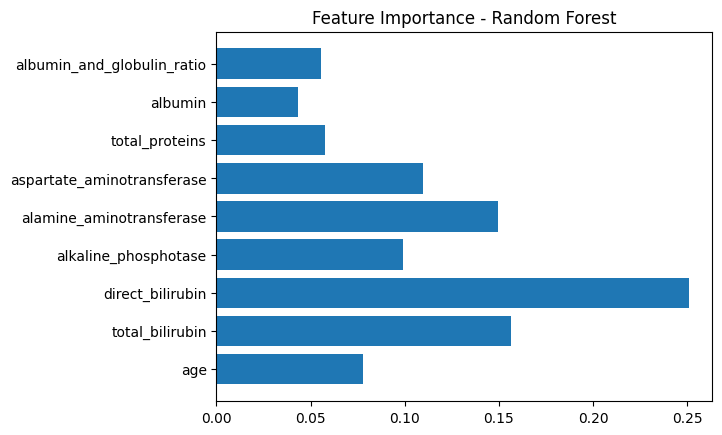

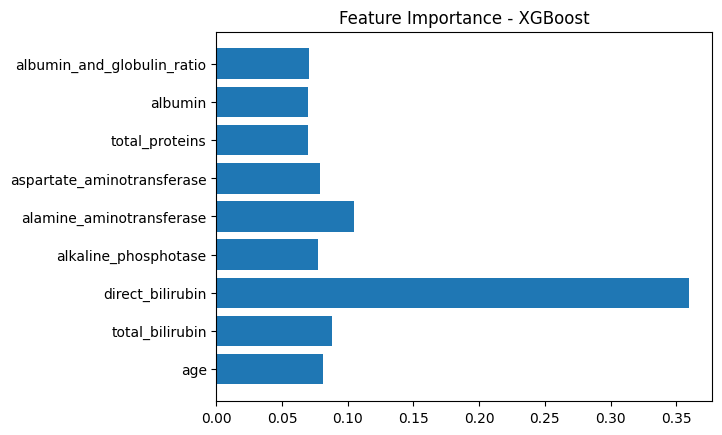

In [294]:
import matplotlib.pyplot as plt

# Feature importance for Random Forest
rf_importance = rf_model.feature_importances_
plt.barh(X.columns, rf_importance)
plt.title("Feature Importance - Random Forest")
plt.show()

# Feature importance for XGBoost
xgb_importance = xgb_model.feature_importances_
plt.barh(X.columns, xgb_importance)
plt.title("Feature Importance - XGBoost")
plt.show()


In [295]:
from sklearn.model_selection import GridSearchCV

# Example for XGBoost tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid_xgb = GridSearchCV(XGBClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_xgb.fit(X_train_scaled, y_train)

print("Best XGB parameters:", grid_xgb.best_params_)


Best XGB parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


In [296]:
# Drop low-importance features
low_importance_features = ["albumin_and_globulin_ratio", "albumin"]
X_train_filtered = X_train.drop(columns=low_importance_features)
X_test_filtered = X_test.drop(columns=low_importance_features)


In [297]:
selected_features = ['age', 'total_bilirubin', 'alkaline_phosphotase', 'aspartate_aminotransferase', 'total_proteins','direct_bilirubin']
Ldata_s= Ldata[selected_features]


In [298]:
print(Ldata_s.head())  # Check the new DataFrame with selected features

   age  total_bilirubin  alkaline_phosphotase  aspartate_aminotransferase  \
0   65         0.115790              0.150373                    0.145559   
1   62         0.143750              0.151848                    0.149453   
2   62         0.141931              0.151499                    0.148785   
3   58         0.122529              0.150336                    0.145886   
4   72         0.138122              0.150428                    0.148516   

   total_proteins  direct_bilirubin  
0             6.8          0.057444  
1             7.5          0.140381  
2             7.0          0.138480  
3             6.8          0.102284  
4             7.3          0.132109  


In [299]:
X=Ldata_s
y=Ldata['dataset']

In [300]:
print(Ldata['dataset'].value_counts())


dataset
0    406
1    164
Name: count, dtype: int64


In [301]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_test_smote, y_test_smote = smote.fit_resample(X_test, y_test)
print("Original Training Set:", pd.Series(y_train).value_counts())
print("SMOTE Applied Training Set:", pd.Series(y_train_smote).value_counts())
# Initialize StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test_smote)

Original Training Set: dataset
0    325
1    131
Name: count, dtype: int64
SMOTE Applied Training Set: dataset
0    325
1    325
Name: count, dtype: int64


In [302]:
# ✅ Step 5: Initialize individual models
lr_model = LogisticRegression()
xgb_model = RandomForestClassifier(n_estimators=100, random_state=42)  # Using RF in place of XGBoost for consistency
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# ✅ Step 6: Train models with scaled features
lr_model.fit(X_train_scaled, y_train_smote)
xgb_model.fit(X_train_scaled, y_train_smote)
rf_model.fit(X_train_scaled, y_train_smote)

# ✅ Step 7: Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

# ✅ Step 8: Evaluate models
print("Logistic Regression:\n", classification_report(y_test_smote, y_pred_lr))
print("Random Forest:\n", classification_report(y_test_smote, y_pred_xgb))
print("Random Forest (RF):\n", classification_report(y_test_smote, y_pred_rf))


Logistic Regression:
               precision    recall  f1-score   support

           0       0.81      0.58      0.68        81
           1       0.67      0.86      0.76        81

    accuracy                           0.72       162
   macro avg       0.74      0.72      0.72       162
weighted avg       0.74      0.72      0.72       162

Random Forest:
               precision    recall  f1-score   support

           0       0.70      0.77      0.73        81
           1       0.74      0.67      0.70        81

    accuracy                           0.72       162
   macro avg       0.72      0.72      0.72       162
weighted avg       0.72      0.72      0.72       162

Random Forest (RF):
               precision    recall  f1-score   support

           0       0.70      0.77      0.73        81
           1       0.74      0.67      0.70        81

    accuracy                           0.72       162
   macro avg       0.72      0.72      0.72       162
weighted avg   

In [303]:

# ✅ Step 9: Train Voting Classifier using Logistic Regression & Random Forest
voting_clf = VotingClassifier(
    estimators=[('lr', lr_model), ('rf', rf_model)],
    voting='soft'
)

voting_clf.fit(X_train_scaled, y_train_smote)
y_pred_voting = voting_clf.predict(X_test_scaled)
print("Voting Classifier:\n", classification_report(y_test_smote, y_pred_voting))

Voting Classifier:
               precision    recall  f1-score   support

           0       0.82      0.63      0.71        81
           1       0.70      0.86      0.77        81

    accuracy                           0.75       162
   macro avg       0.76      0.75      0.74       162
weighted avg       0.76      0.75      0.74       162



In [305]:
import pickle


# ✅ Step 10: Save the Voting Classifier model using pickle
with open("Liver_disease_model.pkl", "wb") as file:
    pickle.dump(voting_clf, file)

print("Updated model trained & saved successfully!")

Updated model trained & saved successfully!
